<a href="https://colab.research.google.com/github/pald22/STAT-4830-NAPPERS-project/blob/main/demo_02_standalone_polymarket_panel_experiments.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Standalone Demo 2 — Polymarket panel experiments

This notebook is self-contained: it does **not** import any project source files or scripts. All five Polymarket daily-panel experiment runners are embedded below.

External input is limited to one checked-in dataset: `polymarket_daily_panel_60plus.csv`. The notebook writes optional tables, figures, and markdown reports under `Outputs/standalone_demo_polymarket_panel_experiments/`, but it does not read any helper code or precomputed output files.

In [ ]:

from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
from typing import Any
import json
import math
import os
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import accuracy_score, brier_score_loss, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)
np.random.seed(42)


def find_data_file(filename: str, known_dirs: tuple[str, ...]) -> Path:
    """Locate a project dataset without importing any project package.

    The notebook is meant to run from the repository root, from notebooks/, or
    from a folder containing the two CSV datasets. Optional environment variable
    NAPPERS_DATA_DIR may point to a directory containing the data files.
    """
    roots: list[Path] = []
    env = os.environ.get("NAPPERS_DATA_DIR")
    if env:
        roots.append(Path(env).expanduser().resolve())
    cwd = Path.cwd().resolve()
    roots.extend([cwd, *cwd.parents])

    candidates: list[Path] = []
    seen: set[str] = set()
    for root in roots:
        for rel_dir in ("", *known_dirs):
            path = root / rel_dir / filename if rel_dir else root / filename
            key = str(path)
            if key not in seen:
                seen.add(key)
                candidates.append(path)

    for path in candidates:
        if path.is_file():
            return path

    msg = "Could not find dataset {0}. Checked:\n".format(filename)
    msg += "\n".join("  - " + str(p) for p in candidates[:40])
    raise FileNotFoundError(msg)


def infer_project_root_from_data(*paths: Path) -> Path:
    """Use the dataset location to choose an output directory root."""
    for path in paths:
        for parent in path.resolve().parents:
            if (parent / "data").is_dir():
                return parent
    return Path.cwd().resolve()

PANEL_CSV = find_data_file("polymarket_daily_panel_60plus.csv", ("data/prediction_market", "prediction_market", "data"))

print("Polymarket dataset:", PANEL_CSV)


Polymarket dataset: /content/polymarket_daily_panel_60plus.csv


## Function block — loaders, feature engineering, split checks, and experiments

This block embeds the full panel-experiment logic: daily feature construction, leakage-safe chronological splits, five experiment runners, and markdown report writing.

In [ ]:

# ---------------------------------------------------------
# Standalone Polymarket daily-panel experiment functions
# ---------------------------------------------------------

@dataclass
class SplitSpec:
    train_end: pd.Timestamp
    valid_end: pd.Timestamp


def load_panel(csv_path: Path) -> pd.DataFrame:
    df = pd.read_csv(csv_path, low_memory=False)
    df["date"] = pd.to_datetime(df["date"], utc=True, errors="coerce")
    df["end_date_iso"] = pd.to_datetime(df["end_date_iso"], utc=True, errors="coerce")
    for c in ("price", "volume", "liquidity"):
        df[c] = pd.to_numeric(df[c], errors="coerce")
    df = df.dropna(subset=["market_id", "date", "price"]).copy()
    df = df.sort_values(["market_id", "date"]).reset_index(drop=True)
    return df


def add_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    g = out.groupby("market_id", group_keys=False)
    out["ret_1d"] = g["price"].pct_change()
    out["ret_7d"] = g["price"].pct_change(7)
    out["price_lag_1"] = g["price"].shift(1)
    out["price_lag_7"] = g["price"].shift(7)
    out["ret_1d_lag_1"] = g["ret_1d"].shift(1)
    out["ret_7d_lag_1"] = g["ret_7d"].shift(1)
    out["mom_3d"] = g["ret_1d"].rolling(3).sum().reset_index(level=0, drop=True)
    out["mom_7d"] = g["ret_1d"].rolling(7).sum().reset_index(level=0, drop=True)
    out["vol_7d"] = g["ret_1d"].rolling(7).std().reset_index(level=0, drop=True)
    out["vol_21d"] = g["ret_1d"].rolling(21).std().reset_index(level=0, drop=True)
    out["days_to_end"] = (out["end_date_iso"] - out["date"]).dt.total_seconds() / 86400.0
    out["log_volume"] = np.log1p(out["volume"].clip(lower=0))
    out["log_liquidity"] = np.log1p(out["liquidity"].clip(lower=0))
    out["illiq_proxy"] = np.abs(out["ret_1d"]) / np.maximum(out["volume"], 1.0)
    out["target_1d"] = g["ret_1d"].shift(-1)
    out["target_7d"] = g["ret_1d"].shift(-7)
    out["liq_rank_pct"] = out.groupby("date")["liquidity"].rank(pct=True)
    out["price_rank_pct"] = out.groupby("date")["price"].rank(pct=True)
    out["ret_rank_pct"] = out.groupby("date")["ret_1d"].rank(pct=True)
    out["cs_mispricing"] = out["price"] - out.groupby("date")["price"].transform("median")
    out["liq_x_mom7"] = out["liq_rank_pct"] * out["mom_7d"]
    out["illiq_x_mom7"] = out["illiq_proxy"] * out["mom_7d"]
    return out


def make_split(df: pd.DataFrame, split: SplitSpec) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    train = df[df["date"] <= split.train_end].copy()
    valid = df[(df["date"] > split.train_end) & (df["date"] <= split.valid_end)].copy()
    test = df[df["date"] > split.valid_end].copy()
    return train, valid, test


def split_60_20_20(df: pd.DataFrame) -> SplitSpec:
    dates = np.sort(df["date"].dropna().unique())
    n = len(dates)
    i1 = int(n * 0.6)
    i2 = int(n * 0.8)
    return SplitSpec(train_end=pd.Timestamp(dates[i1 - 1]), valid_end=pd.Timestamp(dates[i2 - 1]))


def feature_cols() -> list[str]:
    return [
        "price_lag_1",
        "price_lag_7",
        "ret_1d_lag_1",
        "ret_7d_lag_1",
        "mom_3d",
        "mom_7d",
        "vol_7d",
        "vol_21d",
        "days_to_end",
        "log_volume",
        "log_liquidity",
        "illiq_proxy",
        "liq_rank_pct",
        "price_rank_pct",
        "ret_rank_pct",
        "cs_mispricing",
        "liq_x_mom7",
        "illiq_x_mom7",
    ]


def sanitize_xy(df: pd.DataFrame, y_col: str) -> tuple[pd.DataFrame, pd.Series]:
    cols = feature_cols()
    keep = cols + ["date", "market_id", "liquidity", "category", "days_to_end", "question", y_col]
    xdf = df[keep].replace([np.inf, -np.inf], np.nan).dropna(subset=[y_col]).copy()
    med = xdf[cols].median(numeric_only=True).fillna(0.0)
    x = xdf[cols].fillna(med).fillna(0.0)
    y = xdf[y_col]
    return x, y


def rank_ic(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    value = pd.Series(y_true).corr(pd.Series(y_pred), method="spearman")
    return float(value) if pd.notna(value) else np.nan


def sanity_check_no_overlap(train: pd.DataFrame, valid: pd.DataFrame, test: pd.DataFrame) -> dict[str, bool]:
    key = lambda d: set(zip(d["market_id"].astype(str), d["date"].astype(str)))
    kt, kv, ks = key(train), key(valid), key(test)
    chrono_ok = True
    if len(train) and len(valid):
        chrono_ok = chrono_ok and (train["date"].max() <= valid["date"].min())
    if len(valid) and len(test):
        chrono_ok = chrono_ok and (valid["date"].max() <= test["date"].min())
    if len(train) and len(test) and not len(valid):
        chrono_ok = chrono_ok and (train["date"].max() <= test["date"].min())
    return {
        "no_train_valid_overlap": len(kt & kv) == 0,
        "no_train_test_overlap": len(kt & ks) == 0,
        "no_valid_test_overlap": len(kv & ks) == 0,
        "chrono_order": bool(chrono_ok),
    }


def run_exp_01(df: pd.DataFrame) -> dict[str, Any]:
    split = split_60_20_20(df)
    train, valid, test = make_split(df, split)
    checks = sanity_check_no_overlap(train, valid, test)
    xtr, ytr = sanitize_xy(train, "target_1d")
    xva, yva = sanitize_xy(valid, "target_1d")
    xte, yte = sanitize_xy(test, "target_1d")
    scaler = StandardScaler()
    xtr_s = scaler.fit_transform(xtr)
    xva_s = scaler.transform(xva)
    xte_s = scaler.transform(xte)

    ridge_grid = [0.1, 1.0, 5.0, 20.0]
    best_alpha, best_mae = None, np.inf
    for alpha in ridge_grid:
        m = Ridge(alpha=alpha)
        m.fit(xtr_s, ytr)
        pred = m.predict(xva_s)
        mae = mean_absolute_error(yva, pred)
        if mae < best_mae:
            best_mae = mae
            best_alpha = alpha
    model = Ridge(alpha=float(best_alpha))
    model.fit(xtr_s, ytr)
    pred_te = model.predict(xte_s)
    pred_prob = 1.0 / (1.0 + np.exp(-pred_te * 10.0))
    dir_true = (yte > 0).astype(int)
    dir_pred = (pred_te > 0).astype(int)
    spread = 0.003
    tc = spread + 0.02 * (1.0 / np.maximum(test.loc[yte.index, "liquidity"].values, 1.0))
    w = np.clip(pred_te / (np.nanstd(pred_te) + 1e-9), -1.0, 1.0)
    gross = w * yte.values
    net = gross - np.abs(w) * tc
    turnover = float(np.mean(np.abs(np.diff(w)))) if len(w) > 1 else 0.0
    metrics = {
        "r2_test": float(r2_score(yte, pred_te)),
        "mae_test": float(mean_absolute_error(yte, pred_te)),
        "directional_accuracy_test": float(accuracy_score(dir_true, dir_pred)),
        "rank_ic_test": rank_ic(yte.values, pred_te),
        "brier_directional_test": float(brier_score_loss(dir_true, pred_prob)),
        "net_mean_return_test": float(np.mean(net)),
        "gross_mean_return_test": float(np.mean(gross)),
        "net_sharpe_test": float(np.mean(net) / (np.std(net) + 1e-9) * np.sqrt(252.0)),
        "turnover_test": turnover,
        "best_alpha_from_validation": float(best_alpha),
    }
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(np.cumsum(gross), label="gross")
    ax.plot(np.cumsum(net), label="net")
    ax.set_title("Exp 1 cumulative gross vs net PnL")
    ax.legend()
    fig.tight_layout()
    q = pd.qcut(pred_te, 10, labels=False, duplicates="drop")
    decile = pd.DataFrame({"q": q, "ret": yte.values}).groupby("q")["ret"].mean().reset_index()
    checks.update({
        "validation_only_selection": True,
        "features_use_lag_only": True,
        "cost_stress_plus50_net_positive": float(np.mean(gross - np.abs(w) * tc * 1.5)) > 0.0,
    })
    return {"metrics": metrics, "checks": checks, "artifacts": [], "tables": {"decile_returns": decile}, "plot_data": {"gross": gross, "net": net}}


def run_exp_02(df: pd.DataFrame) -> dict[str, Any]:
    split = split_60_20_20(df)
    train, valid, test = make_split(df, split)
    checks = sanity_check_no_overlap(train, valid, test)
    xtr, ytr = sanitize_xy(train, "target_1d")
    xte, yte = sanitize_xy(test, "target_1d")
    scaler = StandardScaler()
    xtr_s, xte_s = scaler.fit_transform(xtr), scaler.transform(xte)
    model = Ridge(alpha=5.0).fit(xtr_s, ytr)
    pred_te = model.predict(xte_s)
    tdf = test.loc[yte.index].copy()
    train_q = pd.qcut(train["liquidity"].fillna(0), 5, retbins=True, duplicates="drop")[1]
    tdf["liq_bucket"] = pd.cut(tdf["liquidity"], bins=train_q, include_lowest=True, labels=False)
    grouped = []
    for b, g in pd.DataFrame({"b": tdf["liq_bucket"], "y": yte.values, "p": pred_te}).dropna().groupby("b"):
        grouped.append({"b": b, "rank_ic": rank_ic(g["y"].values, g["p"].values), "mae": mean_absolute_error(g["y"], g["p"])})
    grp = pd.DataFrame(grouped)
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.bar(grp["b"].astype(str), grp["rank_ic"])
    ax.set_title("Exp 2 rank IC by liquidity bucket")
    fig.tight_layout()
    checks["bucket_cutoffs_from_train_only"] = True
    return {"metrics": {"mean_bucket_rank_ic": float(grp["rank_ic"].mean())}, "checks": checks, "artifacts": [], "tables": {"bucket_metrics": grp}}


def run_exp_03(df: pd.DataFrame) -> dict[str, Any]:
    split = split_60_20_20(df)
    train, _, test = make_split(df, split)
    checks = sanity_check_no_overlap(train, test.iloc[:0], test)
    xtr, ytr = sanitize_xy(train, "target_1d")
    xte, yte = sanitize_xy(test, "target_1d")
    base_cols = [c for c in feature_cols() if c not in ("ret_rank_pct", "cs_mispricing")]
    xtr_base, xte_base = xtr[base_cols], xte[base_cols]
    sc_base = StandardScaler().fit(xtr_base)
    base = Ridge(alpha=5.0).fit(sc_base.transform(xtr_base), ytr)
    fsc = StandardScaler().fit(xtr)
    full = Ridge(alpha=5.0).fit(fsc.transform(xtr), ytr)
    pred_base = base.predict(sc_base.transform(xte_base))
    pred_full = full.predict(fsc.transform(xte))
    delta_r2 = float(r2_score(yte, pred_full) - r2_score(yte, pred_base))
    table = pd.DataFrame([{"delta_r2": delta_r2, "rank_ic_base": rank_ic(yte.values, pred_base), "rank_ic_full": rank_ic(yte.values, pred_full)}])
    checks["factor_definitions_train_frozen"] = True
    return {"metrics": {"delta_r2_full_minus_base": delta_r2}, "checks": checks, "artifacts": [], "tables": {"incremental": table}}


def run_exp_04(df: pd.DataFrame) -> dict[str, Any]:
    split = split_60_20_20(df)
    train, valid, test = make_split(df, split)
    checks = sanity_check_no_overlap(train, valid, test)
    xtr, ytr = sanitize_xy(train, "target_1d")
    xva, yva = sanitize_xy(valid, "target_1d")
    xte, yte = sanitize_xy(test, "target_1d")
    scaler = StandardScaler()
    xtr_s, xva_s, xte_s = scaler.fit_transform(xtr), scaler.transform(xva), scaler.transform(xte)
    rf = RandomForestRegressor(n_estimators=200, max_depth=7, random_state=42, n_jobs=-1)
    rf.fit(xtr_s, ytr)
    pred_va = rf.predict(xva_s)
    pred_te = rf.predict(xte_s)
    residual_scale = float(np.std(yva - pred_va))
    tmeta = test.loc[yte.index]
    haircut = 1.0 / (1.0 + np.maximum(tmeta["days_to_end"].fillna(30.0).values, 0.0) / 30.0)
    pred_adj = pred_te * haircut
    pdir = 1.0 / (1.0 + np.exp(-pred_adj * 10.0))
    ydir = (yte > 0).astype(int)
    cov = float(np.mean((np.abs(yte - pred_adj) <= residual_scale).astype(float)))
    metrics = {
        "brier_directional": float(brier_score_loss(ydir, pdir)),
        "interval_coverage_1sigma": cov,
        "mae_adjusted": float(mean_absolute_error(yte, pred_adj)),
    }
    table = pd.DataFrame([metrics])
    checks["proxy_labels_no_terminal_outcome_peeking"] = True
    checks["haircut_tuned_on_validation"] = True
    return {"metrics": metrics, "checks": checks, "artifacts": [], "tables": {"reliability": table}}


def run_exp_05(df: pd.DataFrame) -> dict[str, Any]:
    checks: dict[str, bool] = {}
    results: list[dict[str, Any]] = []
    dates = np.sort(df["date"].dropna().unique())
    horizons = {"single_holdout": (0.6, 0.2), "expanding": (0.5, 0.15), "rolling": (0.45, 0.15)}
    for name, (tr_ratio, va_ratio) in horizons.items():
        i1 = max(1, int(len(dates) * tr_ratio))
        i2 = max(i1 + 1, int(len(dates) * (tr_ratio + va_ratio)))
        split = SplitSpec(pd.Timestamp(dates[i1 - 1]), pd.Timestamp(dates[min(i2 - 1, len(dates) - 1)]))
        train, valid, test = make_split(df, split)
        sc = sanity_check_no_overlap(train, valid, test)
        checks.update({f"{name}_{k}": v for k, v in sc.items()})
        xtr, ytr = sanitize_xy(train, "target_1d")
        xva, yva = sanitize_xy(valid, "target_1d")
        xte, yte = sanitize_xy(test, "target_1d")
        sca = StandardScaler()
        xtr_s, xva_s, xte_s = sca.fit_transform(xtr), sca.transform(xva), sca.transform(xte)
        rows = []
        for a in [0.1, 1.0, 5.0, 20.0]:
            m = Ridge(alpha=a).fit(xtr_s, ytr)
            rows.append((a, mean_absolute_error(yva, m.predict(xva_s))))
        best = min(rows, key=lambda z: z[1])[0]
        m = Ridge(alpha=best).fit(xtr_s, ytr)
        val_score = -mean_absolute_error(yva, m.predict(xva_s))
        test_score = -mean_absolute_error(yte, m.predict(xte_s))
        results.append({"splitter": name, "best_alpha": best, "val_score": float(val_score), "test_score": float(test_score)})
    rdf = pd.DataFrame(results)
    rdf["selection_gap"] = rdf["test_score"] - rdf["val_score"]
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.scatter(rdf["val_score"], rdf["test_score"])
    for _, r in rdf.iterrows():
        ax.text(r["val_score"], r["test_score"], r["splitter"])
    ax.set_xlabel("validation score")
    ax.set_ylabel("test score")
    ax.set_title("Exp 5 validation vs test by splitter")
    fig.tight_layout()
    checks["validation_only_tuning"] = True
    return {"metrics": {"val_test_corr": float(rdf["val_score"].corr(rdf["test_score"]))}, "checks": checks, "artifacts": [], "tables": {"splitter_compare": rdf}}



## Load panel and build features

This is the only dataset read in the notebook. Feature construction adds lagged returns, rolling momentum/volatility, maturity, liquidity, illiquidity, cross-sectional ranks, and next-step targets.

In [ ]:

panel_raw = load_panel(PANEL_CSV)
panel = add_features(panel_raw)

summary = {
    "rows": len(panel),
    "markets": int(panel["market_id"].nunique()),
    "dates": int(panel["date"].nunique()),
    "date_min": str(panel["date"].min().date()),
    "date_max": str(panel["date"].max().date()),
    "columns_after_features": len(panel.columns),
}
display(pd.DataFrame([summary]))
display(panel.head(3))


,rows,markets,dates,date_min,date_max,columns_after_features
0,64076,275,354,2025-05-03,2026-04-21,38


,market_id,question,slug,token_id,date,datetime_utc,timestamp,price,volume,liquidity,active,closed,end_date_iso,category,outcomes,outcomePrices,ret_1d,ret_7d,price_lag_1,price_lag_7,ret_1d_lag_1,ret_7d_lag_1,mom_3d,mom_7d,vol_7d,vol_21d,days_to_end,log_volume,log_liquidity,illiq_proxy,target_1d,target_7d,liq_rank_pct,price_rank_pct,ret_rank_pct,cs_mispricing,liq_x_mom7,illiq_x_mom7
0,540819,Will Jesus Christ return before GTA VI?,will-jesus-christ-return-before-gta-vi-665,9043581125366557801495738082650599253005407769...,2025-05-03 00:00:00+00:00,2025-05-03 00:00:06+00:00,1746230406,0.115,1.111280e+07,829169.3544,True,False,2026-07-31 12:00:00+00:00,NaN,"[""Yes"", ""No""]","[""0.485"", ""0.515""]",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,454.5,16.223608,13.628181,NaN,0.043478,0.043478,1.0,0.333333,NaN,-0.04,NaN,NaN
1,540819,Will Jesus Christ return before GTA VI?,will-jesus-christ-return-before-gta-vi-665,9043581125366557801495738082650599253005407769...,2025-05-04 00:00:00+00:00,2025-05-04 00:00:05+00:00,1746316805,0.120,1.111280e+07,829169.3544,True,False,2026-07-31 12:00:00+00:00,NaN,"[""Yes"", ""No""]","[""0.485"", ""0.515""]",0.043478,NaN,0.115,NaN,NaN,NaN,NaN,NaN,NaN,NaN,453.5,16.223608,13.628181,3.912449e-09,0.000000,0.041667,1.0,0.333333,0.666667,-0.01,NaN,NaN
2,540819,Will Jesus Christ return before GTA VI?,will-jesus-christ-return-before-gta-vi-665,9043581125366557801495738082650599253005407769...,2025-05-05 00:00:00+00:00,2025-05-05 00:00:05+00:00,1746403205,0.120,1.111280e+07,829169.3544,True,False,2026-07-31 12:00:00+00:00,NaN,"[""Yes"", ""No""]","[""0.485"", ""0.515""]",0.000000,NaN,0.120,NaN,0.043478,NaN,NaN,NaN,NaN,NaN,452.5,16.223608,13.628181,0.000000e+00,0.041667,0.040000,1.0,0.333333,0.666667,-0.02,NaN,NaN


In [ ]:

split = split_60_20_20(panel)
train, valid, test = make_split(panel, split)

split_table = pd.DataFrame([
    {"split": "train", "rows": len(train), "dates": train["date"].nunique(), "start": train["date"].min(), "end": train["date"].max()},
    {"split": "validation", "rows": len(valid), "dates": valid["date"].nunique(), "start": valid["date"].min(), "end": valid["date"].max()},
    {"split": "test", "rows": len(test), "dates": test["date"].nunique(), "start": test["date"].min(), "end": test["date"].max()},
])
display(split_table)
display(pd.DataFrame([sanity_check_no_overlap(train, valid, test)]))


,split,rows,dates,start,end
0,train,30367,212,2025-05-03 00:00:00+00:00,2025-11-30 00:00:00+00:00
1,validation,19339,71,2025-12-01 00:00:00+00:00,2026-02-09 00:00:00+00:00
2,test,14370,71,2026-02-10 00:00:00+00:00,2026-04-21 00:00:00+00:00


,no_train_valid_overlap,no_train_test_overlap,no_valid_test_overlap,chrono_order
0,True,True,True,True


## Run the five panel experiments

Each runner returns metrics, sanity checks, in-memory result tables, and optional saved artifacts.

Running Experiment 1: Persistent Predictability
Running Experiment 2: Liquidity and Forecastability
Running Experiment 3: Cross-Sectional Factors
Running Experiment 4: Unresolved Market Risk
Running Experiment 5: Validation Design
Completed all panel experiments. Results are stored in the in-memory `results` dictionary.


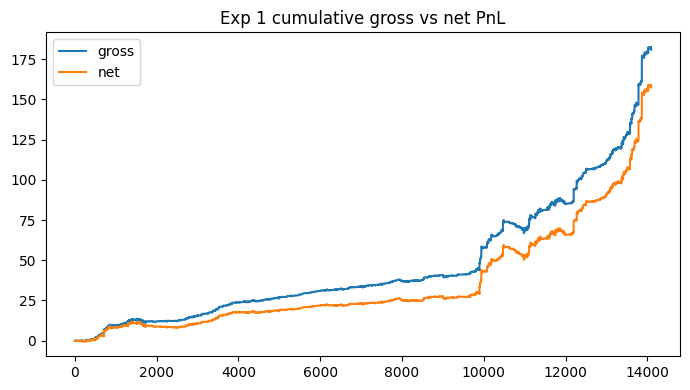

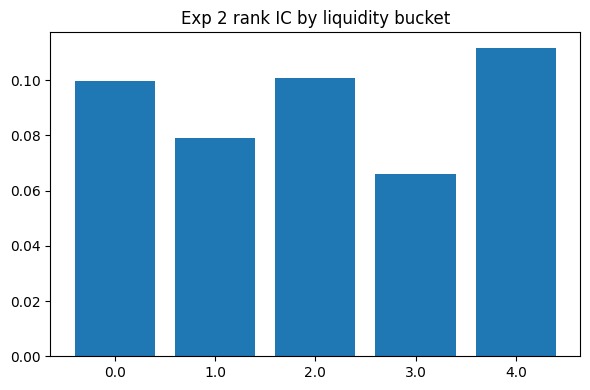

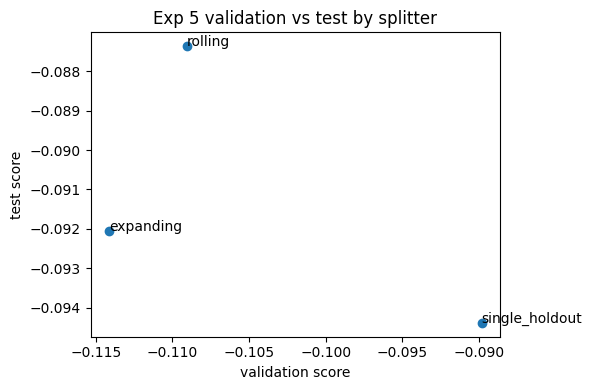

In [ ]:
experiment_runs = [
    ("Experiment 1: Persistent Predictability", run_exp_01),
    ("Experiment 2: Liquidity and Forecastability", run_exp_02),
    ("Experiment 3: Cross-Sectional Factors", run_exp_03),
    ("Experiment 4: Unresolved Market Risk", run_exp_04),
    ("Experiment 5: Validation Design", run_exp_05),
]

results: dict[str, dict[str, Any]] = {}
for name, fn in experiment_runs:
    print("Running", name)
    results[name] = fn(panel)

print("Completed all panel experiments. Results are stored in the in-memory `results` dictionary.")


In [ ]:

metric_rows = []
check_rows = []
for name, result in results.items():
    short = name.split(":", 1)[0].replace("Experiment ", "Exp ")
    row = {"experiment": short}
    row.update(result["metrics"])
    metric_rows.append(row)
    for check, ok in result["checks"].items():
        check_rows.append({"experiment": short, "check": check, "pass": bool(ok)})

metrics_df = pd.DataFrame(metric_rows)
checks_df = pd.DataFrame(check_rows)

display(metrics_df.round(6))
print("All sanity checks passed:", bool(checks_df["pass"].all()))
display(checks_df.groupby("experiment")["pass"].agg(["count", "sum"]).rename(columns={"count": "checks", "sum": "passed"}))


,experiment,r2_test,mae_test,directional_accuracy_test,rank_ic_test,brier_directional_test,net_mean_return_test,gross_mean_return_test,net_sharpe_test,turnover_test,best_alpha_from_validation,mean_bucket_rank_ic,delta_r2_full_minus_base,brier_directional,interval_coverage_1sigma,mae_adjusted,val_test_corr
0,Exp 1,-0.018686,0.094381,0.536219,0.076922,0.275184,0.011162,0.01283,0.769515,0.261529,20.0,NaN,NaN,NaN,NaN,NaN,NaN
1,Exp 2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.091454,NaN,NaN,NaN,NaN,NaN
2,Exp 3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.008002,NaN,NaN,NaN,NaN
3,Exp 4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.258464,0.946861,0.072471,NaN
4,Exp 5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.609073


All sanity checks passed: True


,checks,passed
experiment,,
Exp 1,7,7
Exp 2,5,5
Exp 3,5,5
Exp 4,6,6
Exp 5,13,13


## Representative output tables and plots

The following cells use the in-memory objects returned by the experiment functions. They do not read precomputed CSV or PNG files.

,q,ret
0,0,-0.017131
1,1,-0.008271
2,2,-0.000871
3,3,0.000077
4,4,-0.004865
5,5,-0.002463
6,6,0.004113
7,7,0.009493
8,8,0.029064
9,9,0.068537


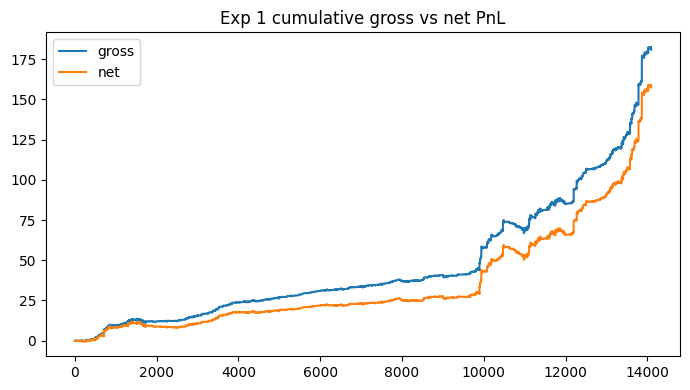

In [ ]:

# Experiment 1: decile returns and cumulative gross/net PnL.
exp1 = results["Experiment 1: Persistent Predictability"]
display(exp1["tables"]["decile_returns"].round(6))
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(np.cumsum(exp1["plot_data"]["gross"]), label="gross")
ax.plot(np.cumsum(exp1["plot_data"]["net"]), label="net")
ax.set_title("Exp 1 cumulative gross vs net PnL")
ax.legend()
plt.tight_layout()
plt.show()


,b,rank_ic,mae
0,0.0,0.099769,0.165697
1,1.0,0.079080,0.084373
2,2.0,0.100608,0.086600
3,3.0,0.066105,0.071613
4,4.0,0.111707,0.056294


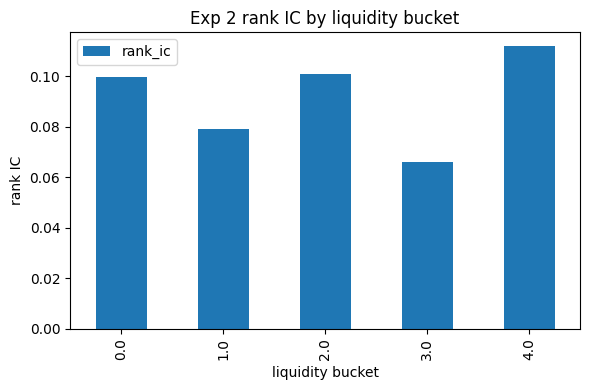

In [ ]:

# Experiment 2: signal quality by train-defined liquidity bucket.
exp2 = results["Experiment 2: Liquidity and Forecastability"]
exp2_buckets = exp2["tables"]["bucket_metrics"]
display(exp2_buckets.round(6))
ax = exp2_buckets.plot.bar(x="b", y="rank_ic", figsize=(6, 4), title="Exp 2 rank IC by liquidity bucket")
ax.set_xlabel("liquidity bucket")
ax.set_ylabel("rank IC")
plt.tight_layout()
plt.show()


In [ ]:

# Experiments 3 and 4: compact result tables.
exp3 = results["Experiment 3: Cross-Sectional Factors"]["tables"]["incremental"]
exp4 = results["Experiment 4: Unresolved Market Risk"]["tables"]["reliability"]
display(exp3.round(6))
display(exp4.round(6))


,delta_r2,rank_ic_base,rank_ic_full
0,0.008002,0.042423,0.076829


,brier_directional,interval_coverage_1sigma,mae_adjusted
0,0.258464,0.946861,0.072471


,splitter,best_alpha,val_score,test_score,selection_gap
0,single_holdout,20.0,-0.089823,-0.094381,-0.004558
1,expanding,20.0,-0.114124,-0.092057,0.022067
2,rolling,20.0,-0.109032,-0.087368,0.021664


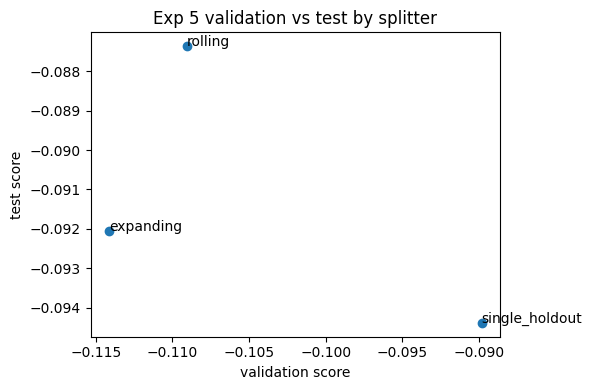

In [ ]:

# Experiment 5: validation-vs-test splitter comparison.
exp5 = results["Experiment 5: Validation Design"]["tables"]["splitter_compare"]
display(exp5.round(6))
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(exp5["val_score"], exp5["test_score"])
for _, r in exp5.iterrows():
    ax.text(r["val_score"], r["test_score"], r["splitter"])
ax.set_xlabel("validation score")
ax.set_ylabel("test score")
ax.set_title("Exp 5 validation vs test by splitter")
plt.tight_layout()
plt.show()


## Reading the standalone results

The important pattern is not a single metric. The suite shows how prediction, liquidity heterogeneity, cross-sectional factors, unresolved-risk haircuts, and validation design interact. A robust deployment should prioritize leakage-safe split governance and ranked/cost-aware signal evaluation over raw point-forecast fit.